## Load Input Data

### _For creating dummy data_

In [ ]:
# from llm_handler import LLMHandler

# prompt = """Aufgabe:
# Erstelle einen realistischen Dummy-Datensatz für das Fachgebiet Data Science.

# Struktur der Daten:
# Die Ausgabe soll eine Liste von Dictionaries sein. Jedes Dictionary repräsentiert eine Prüfungsantwort eines Studierenden und enthält exakt die folgenden Schlüssel:

# question_text – die Prüfungsfrage

# student_answer – eine beispielhafte Antwort eines Studierenden

# gold_answer – eine fachlich korrekte Musterlösung

# maximal_score – die maximal erreichbare Punktzahl (Ganzzahl)

# human_score – die von einer Lehrperson vergebene Punktzahl (Ganzzahl ≤ maximal_score)

# human_feedback – konstruktives, textuelles Feedback zur studentischen Antwort

# Inhaltliche Anforderungen:

# Die Fragen sollen typische Themen aus Data Science abdecken (z. B. Datenvorverarbeitung, Machine Learning, Statistik, Evaluation, Overfitting, Feature Engineering).

# Die studentischen Antworten dürfen unterschiedliche Qualitätsstufen haben (sehr gut, mittelmäßig, fehlerhaft).

# human_score und human_feedback sollen konsistent zur Qualität der Antwort sein.

# Formatierungsanforderungen:

# Gib nur die Liste von Dictionaries aus

# Kein erklärender Text außerhalb der Daten

# Syntax soll JSON-kompatibel sein

# Umfang:

# Erstelle mindestens 15 Einträge im Datensatz"""

# llm_handler = LLMHandler()
# response = llm_handler.call_llm(prompt)
# print(response)

In [ ]:
# import pandas as pd
# pd.DataFrame(response).to_csv("evaluation_data.csv", index=False)

### _Real code starts here_

In [ ]:
import pandas as pd

df = pd.read_csv("evaluation_data.csv")

# check for column names: question_text, student_answer, gold_answer, maximal_score, human_score, human_feedback
df.head()

## Call LLMs

In [ ]:

from llm_handler import LLMHandler

# TODO: Write prompt for evaluation
prompt = """Bitte vergebe bis zu 5 Punkte für die folgende Studentenantwort auf die gegebene Frage. Für die Orientierung bekommst du eine bereitgestellte Musterlösung.
Vergebe die Punkte folgendermaßen:

Inhaltliche Korrektheit
- Wurden die Antwort komplett richtig und vollständig beantwortet, vergebe 5 Punkte
- Wenn nicht, dann vergebe die erreichten Punkte prozentual

Gebe zusätzlich Verbesserungsvorschläge
- Was sollte der Student inhaltlich besser machen?
- Welche Schlüsselpunkte der Musterlösung wurden getroffen?
- Welche Aussagen sind falsch oder unvollständig?

Gib am Ende ein knappes Gesamtrating (0-5 Punkte). Gerundet auf eine Nachkommastelle

Wichtige Regel: Die gesamte Ausgabe muss in deutscher Sprache erfolgen.

Frage:
{question}

Studentenantwort:
{student_answer}

Musterlösung:
{correct_answer}

Für diese Frage gibt es maximal {max_score} Punkte.

<Antwortformat>
```json
{{
"llm_feedback": "<Hier antwortest du auf die Antwort des Studenten und gibts ihm Feedback entsprechend der Analysepunkte. Die Antwort ist ein Text, es gibt keine JSON-Struktur>",
"llm_rating": "<Gesamtrating, maximale Punkte: {max_score}, gerundet auf eine Nachkommastelle>"
}}```
"""

In [ ]:
def _results_current_model(llm: LLMHandler, prompt: str, df: pd.DataFrame) -> pd.DataFrame:
  llm_results = []
  for _, row in df.iterrows():
    prompt_filled = prompt.format(
      question=row['question_text'],
      student_answer=row['student_answer'],
      correct_answer=row['gold_answer'],
      max_score=row['maximal_score']
    )
    answer = llm.call_llm(prompt=prompt_filled)
    answer["question"] = row['question_text']
    answer["student_answer"] = row['student_answer']
    answer["correct_answer"] = row['gold_answer']
    answer["max_score"] = row['maximal_score']
    answer["human_score"] = row['human_score']
    answer["human_feedback"] = row['human_feedback']
    llm_results.append(answer)
  return pd.DataFrame(llm_results)

In [ ]:
models = ["gemma3:27b", "gemma3:4b", "deepseek-r1:8b", "llama3.1:latest", "llava:latest", "command-r7b:latest", "mixtral:latest",
         "mistral-small3.1:latest", "llama3.3:latest", "phi4:latest"]

# for testing purposes
# models = ["deepseek-r1:8b", "llama3.3:latest", "phi4:latest"]

dfs = []

for model in models:
  llm_handler = LLMHandler(model=model)

  df_model = _results_current_model(llm_handler, prompt, df)
  df_model["model"] = model
  dfs.append(df_model)
  
final_df = pd.concat(dfs, ignore_index=True)
final_df.to_csv("llm_evaluation_results.csv", index=False)

## Evaluate LLM Answers

### Semantic Similarity of LLM Feedback with Human Feedback

In [1]:
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

device = torch.device("cpu")

final_df = pd.read_csv("llm_evaluation_results.csv")

semantic_judge = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def _semantic_similarity(a: str, b: str) -> float:
  """Calculate the semantic similarity between two texts using cosine similarity of their embeddings.

  Args:
      a (str): The first text to compare.
      b (str): The second text to compare.

  Returns:
      float: A float value between -1 and 1 indicating the semantic similarity between the two texts.
  """
  emb_a = semantic_judge.encode(a, convert_to_tensor=True).detach().cpu()
  emb_b = semantic_judge.encode(b, convert_to_tensor=True).detach().cpu()

  sim = cosine_similarity(emb_a.reshape(1, -1).numpy(), emb_b.reshape(1, -1).numpy())[0][0]
  
  return float(sim)

/Users/aleks/Desktop/FernUni_Hagen/EchoLearnBrainstorming/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
final_df["semantic_similarity"] = final_df.apply(
  lambda row: _semantic_similarity(row["student_answer"], row["correct_answer"]), axis=1
)

### MAE for LLM Scores and Human Scores

In [4]:
import numpy as np

final_df["llm_rating"] = final_df["llm_rating"].str.replace(",", ".")
final_df["abs_error"] = np.abs(final_df["human_score"] - final_df["llm_rating"].astype(float))
final_df["error_perf"] = 1 - (final_df["abs_error"] / final_df["max_score"])

## Comparison and metrics

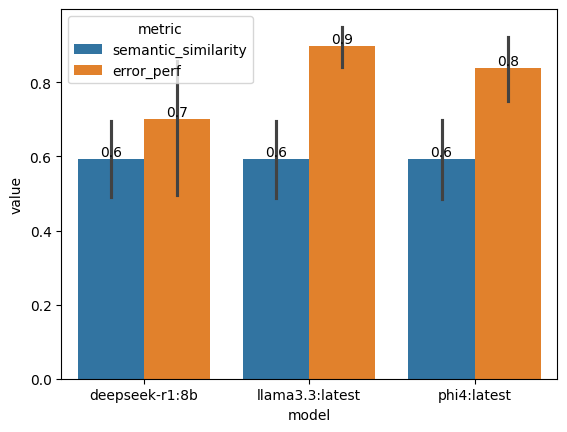

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = final_df.melt(
    id_vars="model",
    value_vars=["semantic_similarity","error_perf"],
    var_name="metric",
    value_name="value"
)

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")
plt.show()